In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.table import Table
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [129]:
band_colors = {
    'LSST-u': '#15284F',   # Fink dark blue
    'LSST-g': '#3c8dff',   # Fink light blue
    'LSST-r': '#4daf4a',   # medium green (distinct from orange)
    'LSST-i': '#f5622e',   # Fink orange (keep original)
    'LSST-z': '#D32F2F',   # red
    'LSST-Y': '#8D6E63'    # brown
}


In [115]:
dic_sntype = {'50':'Kasen','51':'Bulla'}

In [116]:
# Rubin DDFs
data = {
    'Field': ['ELAISS1', 'XMM_LSS', 'ECDFS', 'COSMOS', 'EDFS_a', 'EDFS_b'],
    'RA': [9.45, 35.57, 52.98, 150.11, 58.9, 63.6],
    'DEC': [-44.02, -4.82, -28.12, 2.23, -49.32, -47.6],
    'Gal l': [311.29, 171.1, 224.07, 236.78, 257.9, 254.48],
    'Gal b': [-72.88, -58.91, -54.6, 42.13, -48.46, -45.77],
    'Eclip l': [346.66, 31.59, 40.81, 151.39, 32, 40.97],
    'Eclip b': [-43.2, -17.92, -45.44, -9.34, -66.61, -66.6]
}

ddf_fields = pd.DataFrame(data)
ddf_fields


,Field,RA,DEC,Gal l,Gal b,Eclip l,Eclip b
0,ELAISS1,9.45,-44.02,311.29,-72.88,346.66,-43.20
1,XMM_LSS,35.57,-4.82,171.10,-58.91,31.59,-17.92
2,ECDFS,52.98,-28.12,224.07,-54.60,40.81,-45.44
3,COSMOS,150.11,2.23,236.78,42.13,151.39,-9.34
4,EDFS_a,58.90,-49.32,257.90,-48.46,32.00,-66.61
5,EDFS_b,63.60,-47.60,254.48,-45.77,40.97,-66.60


In [117]:

def convert_fluxcal_to_mag(df):
    """_summary_

    Args:
        df (_type_): _description_
    """
    # Convert fluxcal to magnitude
    df = df.copy()
    df["magnitude"] = -2.5 * np.log10(df["FLUXCAL"]) + 27.5
    df["magnitude error"] = 2.5 / np.log(10) * df["FLUXCALERR"] / df["FLUXCAL"]
    return df

def read_fits(fname, drop_separators=False):
    """Load SNANA formatted data and cast it to a PANDAS dataframe

    Args:
        fname (str): path + name to PHOT.FITS file
        drop_separators (Boolean): if -777 are to be dropped

    Returns:
        (pandas.DataFrame) dataframe from PHOT.FITS file (with ID)
        (pandas.DataFrame) dataframe from HEAD.FITS file
    """

    # load photometry
    dat = Table.read(fname, format="fits")
    df_phot = dat.to_pandas()
    # failsafe
    if df_phot.MJD.values[-1] == -777.0:
        df_phot = df_phot.drop(df_phot.index[-1])
    if df_phot.MJD.values[0] == -777.0:
        df_phot = df_phot.drop(df_phot.index[0])

    # load header
    header = Table.read(fname.replace("PHOT", "HEAD"), format="fits")
    df_header = header.to_pandas()
    # fix to make SNID unique
    
    # Decode bytes and strip whitespace
    df_header["SNID"] = df_header["SNID"].str.decode("utf-8").str.strip()
    # Map SNTYPE and concatenate
    df_header['model_name'] = df_header["SNTYPE"].astype(str).map(dic_sntype)
    suffix = df_header['model_name'][0]
    # to disentangle the SNIDs from the two models (issue with sim, not unique)
    df_header["SNID"] = df_header["SNID"] + f"_{suffix}"


    # add SNID to phot for skimming
    arr_ID = np.empty(len(df_phot), dtype=object)  # allocate as string
    arr_idx = np.where(df_phot["MJD"].values == -777.0)[0]
    arr_idx = np.hstack((np.array([0]), arr_idx, np.array([len(df_phot)])))
    for counter in range(1, len(arr_idx)):
        start, end = arr_idx[counter - 1], arr_idx[counter]
        snid_str = str(df_header.SNID.iloc[counter - 1])
        arr_ID[start:end] = snid_str
    df_phot["SNID"] = arr_ID

    if drop_separators:
        df_phot = df_phot[df_phot.MJD != -777.000]

    df_phot['SNR'] = np.abs(df_phot['FLUXCAL'] / df_phot['FLUXCALERR'])
    df_phot = convert_fluxcal_to_mag(df_phot)
    df_phot["BAND"] = df_phot["BAND"].str.decode('utf-8').str.strip()

    return df_header, df_phot


In [118]:
import glob
df_header_list=[]
df_phot_list=[]
list_to_read = glob.glob("*/*PHOT.FITS.gz")
print(f"Found {len(list_to_read)} PHOT.FITS.gz files to read.")
for fphot in list_to_read:
    df_header_tmp, df_phot_tmp = read_fits(fphot, drop_separators=True)
    print(f"Reading {fphot} with length {len(df_phot_tmp)}")
    df_header_list.append(df_header_tmp)
    df_phot_list.append(df_phot_tmp)
df_header = pd.concat(df_header_list, ignore_index=True)
# Read all PHOT.FITS.gz files and concatenate them    
df_phot = pd.concat(df_phot_list, ignore_index=True)
print(f"Number of light curves: {len(df_header)}")
print(f"Number of photometric points: {df_phot.groupby('SNID').count()['MJD'].median()} +- {df_phot.groupby('SNID').count()['MJD'].std()}")

Found 2 PHOT.FITS.gz files to read.


/Users/amller/miniconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning:

invalid value encountered in log10



Reading PIP_AMR_KN_LSST_KN_BULLA_NOHOST/PIP_AMR_KN_LSST_KN_BULLA_ab08d_NONIaMODEL00-0001_PHOT.FITS.gz with length 131504


/Users/amller/miniconda3/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning:

invalid value encountered in log10



Reading PIP_AMR_KN_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_LSST_KN_KASEN_81c4b_NONIaMODEL00-0001_PHOT.FITS.gz with length 131504
Number of light curves: 11528
Number of photometric points: 18.0 +- 48.28373262494372


In [119]:
df_header.groupby('model_name').count()['SNID']

model_name
Bulla    5764
Kasen    5764
Name: SNID, dtype: int64

In [120]:
dic_gt5 = {}
for typ in df_header.SIM_GENTYPE.unique():
    
    # Select matching SNIDs from df_phot
    sel_snids = df_header[df_header.SIM_GENTYPE == typ].SNID
    print(f"\nNumber of light curves with SIM_GENTYPE = {typ} | {dic_sntype[str(typ)]}: {len(sel_snids)}")

    # Total SNIDs for this SIM_GENTYPE
    total_typ_snids = len(sel_snids)

    # Photometry
    sel = df_phot[df_phot.SNID.isin(sel_snids)]
    print(f"Number of photometric points for this type: {len(sel)}")

    # Compute SNR thresholds
    typ_str = dic_sntype[f"{typ}"]
    dic_gt5[typ_str] = sel[sel['SNR'] > 5]
    snr_gt_5 = dic_gt5[typ_str]['SNID'].nunique()
    snr_gt_3 = sel[sel['SNR'] > 3]['SNID'].nunique()

    # Group by SNID, count how many SNR > 5 measurements each has
    snr_gt5_counts = dic_gt5[typ_str].groupby('SNID').size()

    # Count how many SNIDs have at least two such measurements
    snr_gt5_atleast2 = (snr_gt5_counts >= 2).sum()

    # Group by SNID and check MJD separation
    def has_two_sep_days(group):
        mjds = group['MJD'].sort_values().values
        for i in range(len(mjds)):
            for j in range(i+1, len(mjds)):
                if abs(mjds[j] - mjds[i]) > 1:
                    return True
        return False

    # Apply the function to each group
    snids_with_two_sep_days = dic_gt5[typ_str].groupby('SNID').filter(has_two_sep_days)['SNID'].nunique()
    

    print(f"{snr_gt_5} light curves have 1 detection with SNR > 5 = {snr_gt_5 / total_typ_snids * 100:.2f}% of this type")
    print(f"{snr_gt5_atleast2} light curves have 2 detections with SNR > 5 = {snr_gt5_atleast2 / total_typ_snids * 100:.2f}% of this type")
    print(f"{snids_with_two_sep_days} light curves have 2 detections with SNR > 5 in >1 day = {snids_with_two_sep_days / total_typ_snids * 100:.2f}% of this type")

    print("")
    print(f"{snr_gt_3} light curves have 1 detection with SNR > 3 = {snr_gt_3 / total_typ_snids * 100:.2f}% of this type")



Number of light curves with SIM_GENTYPE = 51 | Bulla: 5764
Number of photometric points for this type: 131504
623 light curves have 1 detection with SNR > 5 = 10.81% of this type
365 light curves have 2 detections with SNR > 5 = 6.33% of this type
84 light curves have 2 detections with SNR > 5 in >1 day = 1.46% of this type

1167 light curves have 1 detection with SNR > 3 = 20.25% of this type

Number of light curves with SIM_GENTYPE = 50 | Kasen: 5764
Number of photometric points for this type: 131504
404 light curves have 1 detection with SNR > 5 = 7.01% of this type
236 light curves have 2 detections with SNR > 5 = 4.09% of this type
91 light curves have 2 detections with SNR > 5 in >1 day = 1.58% of this type

937 light curves have 1 detection with SNR > 3 = 16.26% of this type


In [121]:
for typ in dic_gt5.keys():
    # Count number of rows with SNR > 5 per BAND
    snr_gt5_by_band = dic_gt5[typ_str].groupby('BAND').size()

    # Find the BAND with the most such entries
    most_common_band = snr_gt5_by_band.idxmax()
    count_most_common_band = snr_gt5_by_band.max()
    print(f"{typ}: The most common BAND with SNR > 5 is {most_common_band} with {count_most_common_band} entries.")
    print(snr_gt5_by_band)
# Combine SNIDs from both models
snids_all_snr_gt5 = np.concatenate([
    dic_gt5['Bulla'].SNID.values, 
    dic_gt5['Kasen'].SNID.values
])

Bulla: The most common BAND with SNR > 5 is LSST-i with 315 entries.
BAND
LSST-Y     48
LSST-g     65
LSST-i    315
LSST-r    312
LSST-u      4
LSST-z    156
dtype: int64
Kasen: The most common BAND with SNR > 5 is LSST-i with 315 entries.
BAND
LSST-Y     48
LSST-g     65
LSST-i    315
LSST-r    312
LSST-u      4
LSST-z    156
dtype: int64


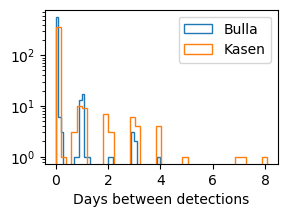

In [122]:
def delta_days(group):
    mjds = group['MJD'].sort_values().values
    for i in range(len(mjds)):
        for j in range(i+1, len(mjds)):
            return mjds[j] - mjds[i]
    return 0
fig = plt.figure(figsize=(3, 2))
for typ in dic_gt5.keys():
    snids_count_sep_days = dic_gt5[typ].groupby('SNID').apply(lambda x: delta_days(x))
    plt.hist(snids_count_sep_days, bins=40, histtype='step',label=typ)
plt.yscale('log')
plt.xlabel('Days between detections')
plt.legend()

Text(0.5, 0, 'Simulated redshift')

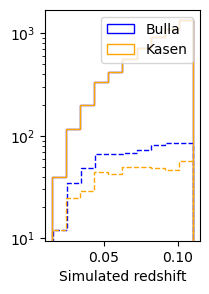

In [123]:
fig = plt.figure(figsize=(2,3))
color_list = ['blue','orange']
for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    plt.hist(sel['SIM_REDSHIFT_CMB'], label=model, histtype='step', color= color_list[m])
    # SNR>5
    sel = sel[sel.SNID.isin(snids_all_snr_gt5)]
    plt.hist(sel['SIM_REDSHIFT_CMB'], histtype='step', color= color_list[m], linestyle='dashed')
plt.legend()
plt.yscale('log')
plt.xlabel('Simulated redshift')

/var/folders/hj/2gy38d5s5mj7n7cln0xf7kjh249zrd/T/ipykernel_99347/562382092.py:19: RuntimeWarning:

invalid value encountered in divide

/var/folders/hj/2gy38d5s5mj7n7cln0xf7kjh249zrd/T/ipykernel_99347/562382092.py:19: RuntimeWarning:

invalid value encountered in divide



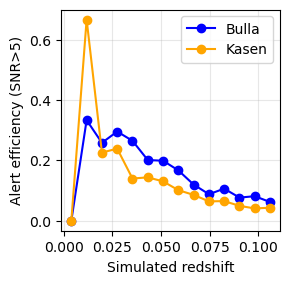

In [124]:
fig = plt.figure(figsize=(3,3))
color_list = ['blue', 'orange']

# Define redshift bins
bins = np.linspace(0, max(df_header['SIM_REDSHIFT_CMB']), 15)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

for m, model in enumerate(df_header.model_name.unique()):
    sel = df_header[df_header.model_name == model]
    
    # All events
    counts_all, _ = np.histogram(sel['SIM_REDSHIFT_CMB'], bins=bins)
    
    # Events with SNR > 5
    sel_snr = sel[sel.SNID.isin(snids_all_snr_gt5)]
    counts_snr, _ = np.histogram(sel_snr['SIM_REDSHIFT_CMB'], bins=bins)
    
    # Efficiency = fraction
    efficiency = counts_snr / counts_all
    efficiency[np.isnan(efficiency)] = 0  # Handle empty bins
    
    plt.plot(bin_centers, efficiency, marker='o', color=color_list[m], label=model)

plt.xlabel('Simulated redshift')
plt.ylabel('Alert efficiency (SNR>5)')
# plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('./paper_plots/efficiency_alert_vs_redshift.png')

### Tag the events in Rubin Deep Drilling Fields

In [125]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

# Initialize new columns
df_header["in_ddf_field"] = False
df_header["ddf_field_name"] = np.nan

# Convert df_header RA/DEC to SkyCoord
coords_header = SkyCoord(ra=df_header["RA"].values * u.deg,
                         dec=df_header["DEC"].values * u.deg)
# Radius of 9.6 deg² -> ~1.75 deg
radius_deg = np.sqrt(9.6 / np.pi)
# Loop through DDF fields
for _, row in ddf_fields.iterrows():
    field = row["Field"]
    ra = row["RA"]
    dec = row["DEC"]
    
    # Convert field center to SkyCoord
    field_coord = SkyCoord(ra=ra * u.deg, dec=dec * u.deg)
    
    # Compute angular separation
    separation = coords_header.separation(field_coord)
    
    # Find objects within radius
    within = separation <= radius_deg * u.deg
    
    df_header.loc[within, "in_ddf_field"] = True
    df_header.loc[within, "ddf_field_name"] = field

# Calculate counts
count_ddf = df_header['in_ddf_field'].sum()
total_count = len(df_header)
total_selected = len(df_header[df_header.SNID.isin(snids_all_snr_gt5)])

print(
    f"# Lcs in DDF fields: {count_ddf} = "
    f"{np.round(count_ddf * 100 / total_count, 2)}% of all lcs = "
    f"{np.round(count_ddf * 100 / total_selected, 2)}% of all lcs SNR>5"
)
print("DDF fields with light curves:")
for field in ddf_fields['Field']:
    count = df_header[df_header['ddf_field_name'] == field].shape[0]
    print(f"{field}: {count} light curves")
# Save the header and photometry dataframes to CSV files

# Lcs in DDF fields: 50 = 0.43% of all lcs = 4.87% of all lcs SNR>5
DDF fields with light curves:
ELAISS1: 6 light curves
XMM_LSS: 14 light curves
ECDFS: 10 light curves
COSMOS: 6 light curves
EDFS_a: 10 light curves
EDFS_b: 4 light curves


/var/folders/hj/2gy38d5s5mj7n7cln0xf7kjh249zrd/T/ipykernel_99347/2195091156.py:58: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



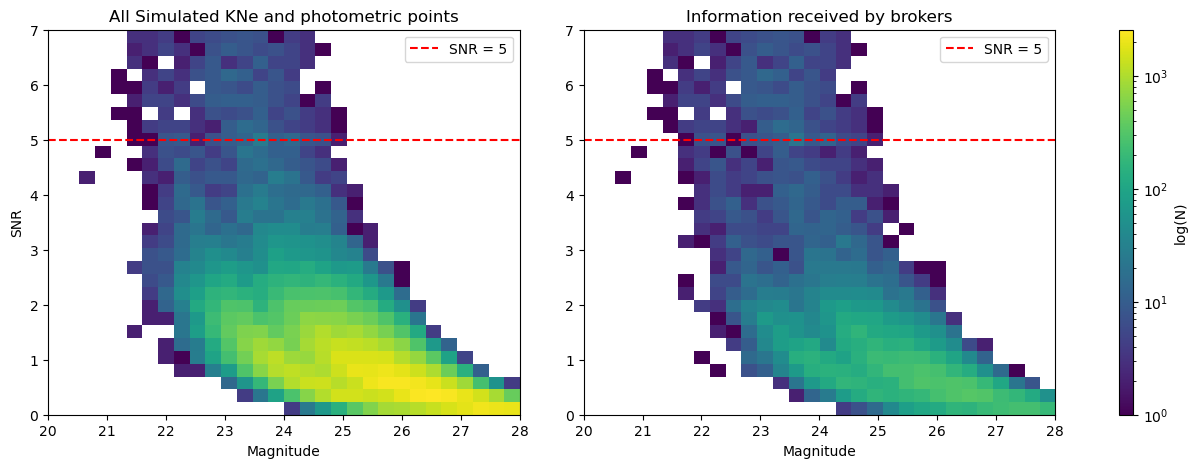

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

# Define bins and ranges
x_bins = 30
y_bins = 30
x_range = [20, 28]
y_range = [0, 7]
bins = [x_bins, y_bins]
range_ = [x_range, y_range]

# Compute 2D histograms manually
H1, _, _ = np.histogram2d(df_phot['magnitude'], df_phot['SNR'],
                          bins=bins, range=range_)
H2, _, _ = np.histogram2d(df_phot[df_phot['SNID'].isin(snids_all_snr_gt5)]['magnitude'], df_phot[df_phot['SNID'].isin(snids_all_snr_gt5)]['SNR'],
                          bins=bins, range=range_)

# Determine global vmin and vmax for LogNorm (exclude zeros)
nonzero_counts = np.concatenate([H1.ravel(), H2.ravel()])
nonzero_counts = nonzero_counts[nonzero_counts > 0]
vmin = nonzero_counts.min()
vmax = nonzero_counts.max()

# Create figure with 3 subplots: 2 main plots + 1 thin colorbar subplot
fig = plt.figure(figsize=(14, 5))
gs = GridSpec(1, 3, width_ratios=[1, 1, 0.03], wspace=0.2)

# First heatmap (left)
ax1 = fig.add_subplot(gs[0])
im1 = ax1.imshow(H1.T, origin='lower',
                 extent=[*x_range, *y_range],
                 aspect='auto', cmap='viridis',
                 norm=LogNorm(vmin=vmin, vmax=vmax))
ax1.set_title('All Simulated KNe and photometric points')
ax1.set_xlabel('Magnitude')
ax1.set_ylabel('SNR')
ax1.axhline(y=5, color='r', linestyle='--', label='SNR = 5')
ax1.legend()

# Second heatmap (middle)
ax2 = fig.add_subplot(gs[1], sharey=ax1)
im2 = ax2.imshow(H2.T, origin='lower',
                 extent=[*x_range, *y_range],
                 aspect='auto', cmap='viridis',
                 norm=LogNorm(vmin=vmin, vmax=vmax))
ax2.set_title('Information received by brokers')
ax2.set_xlabel('Magnitude')
ax2.axhline(y=5, color='r', linestyle='--', label='SNR = 5')
ax2.legend()

# Colorbar subplot (right, very thin)
cax = fig.add_subplot(gs[2])
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label('log(N)')

plt.tight_layout()
plt.show()


In [127]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
import pandas as pd

def plot_lc_subplots(df_phot, df_header, idx, inmag=False, convert_date=False):
    """Plot multi-panel light curve evolution for a given SNID."""
    
    # --- Select data ---
    sel_phot = df_phot[df_phot.SNID == idx].copy()
    sel_header = df_header[df_header.SNID == idx]

    # Remove bogus mags if plotting in mag space
    if inmag:
        sel_phot = sel_phot[sel_phot["magnitude"] > 0]

    # Init
    bands = sel_phot["BAND"].unique()
    x_col = "TIME" if convert_date else "MJD"
    if convert_date:
        sel_phot["TIME"] = pd.to_datetime(sel_phot["MJD"], unit='D', origin='1858-11-17')

    # Peak time for vertical line
    peakmjd = float(sel_header.PEAKMJD.values[0])
    peak_x = pd.to_datetime(peakmjd, unit='D', origin='1858-11-17') if convert_date else peakmjd

    # Select SNR>5 detections sorted by time
    snr5_df = sel_phot[sel_phot['SNR'] > 5].sort_values('MJD')

    # No alerts
    if len(snr5_df)<1:
        print(f"No alert for {idx}")
        return None
    

    # --- Build datasets to plot
    # First alert
    first_alert = snr5_df.head(1)
    # Second alert
    # with history if Delta time> 1 day (0.6 for a night)
    second_alert = pd.DataFrame()
    if len(snr5_df) >= 2:
        if snr5_df['MJD'].iloc[1] - snr5_df['MJD'].iloc[0] > 0.6:
            second_mjd = snr5_df.iloc[1]['MJD']
            snr_lt5_before_second = sel_phot[(sel_phot['SNR'] < 5) & (sel_phot['MJD'] < second_mjd)]
            second_alert = pd.concat([snr5_df.head(2), snr_lt5_before_second])
        else:
            second_alert = snr5_df.head(2)
    # All the photometry received by the broker
    all_alerts = snr5_df
    last_alert_mjd = snr5_df['MJD'].max()
    if snr5_df['MJD'].max() - snr5_df['MJD'].min()>0.6:
        all_alerts = sel_phot[sel_phot['MJD'] < last_alert_mjd]
        
    full_Rubin_lc = sel_phot.copy()

    datasets = [first_alert, second_alert, all_alerts, full_Rubin_lc]

    # --- Global y-range ---
    if inmag:
        all_y = sel_phot["magnitude"]
        ymin, ymax = all_y.max() + 1, all_y.min() - 1  # reversed for mags
    else:
        all_y = sel_phot["FLUXCAL"]
        ymin, ymax = all_y.min() - 1, all_y.max() + 1

    # --- Subplot titles ---
    base_titles = [
        "1. First alert",
        "2. Second alert",
        "3. All broker data",
        "4. Full Rubin data"
    ]
    subplot_titles = []
    for base, df in zip(base_titles, datasets):
        if df.empty:
            latest = "No data"
        else:
            latest_mjd = df['MJD'].max()
            latest = pd.to_datetime(latest_mjd, unit='D', origin='1858-11-17').strftime('%Y-%m-%d') if convert_date else f"MJD {latest_mjd:.1f}"
        subplot_titles.append(f"{base}<br>{latest}")

    # --- Create figure ---
    fig = make_subplots(
        rows=1, cols=4,
        subplot_titles=subplot_titles,
        shared_yaxes=True
    )

    plotted_labels = set()

    # --- Plot each dataset ---
    for i, dataset in enumerate(datasets):
        if dataset.empty:
            continue
        for flt in bands:
            sel_flt = dataset[dataset["BAND"] == flt]
            yvar, yerr = ("magnitude", "magnitude error") if inmag else ("FLUXCAL", "FLUXCALERR")

            # Plot SNR bins
            for snr_min, snr_max, symbol, opacity, suffix in [
                (5, np.inf, 'circle', 1, "SNR > 5"),
                (1, 5, 'circle', 0.3, "1 < SNR < 5")
            ]:
                mask = (sel_flt['SNR'] > snr_min) & (sel_flt['SNR'] < snr_max)
                label = f"{flt} ({suffix})"
                fig.add_trace(go.Scatter(
                    x=sel_flt.loc[mask, x_col],
                    y=sel_flt.loc[mask, yvar],
                    error_y=dict(
                        type='data',
                        array=sel_flt.loc[mask, yerr],
                        visible=True
                    ),
                    mode='markers',
                    name=label,
                    marker=dict(opacity=opacity, symbol=symbol, size=8, color=band_colors.get(flt, 'black')),
                    showlegend=False, #(label not in plotted_labels)
                ), row=1, col=i+1)
                plotted_labels.add(label)

            # SNR < 1
            mask = sel_flt['SNR'] < 1
            fig.add_trace(go.Scatter(
                x=sel_flt.loc[mask, x_col],
                y=sel_flt.loc[mask, yvar],
                mode='markers',
                marker=dict(opacity=0.2, symbol='triangle-down', size=8, color=band_colors.get(flt, 'black')),
                showlegend=False
            ), row=1, col=i+1)

        # Peak & first detection lines
        fig.add_vline(x=peak_x, line=dict(color="black", width=1, dash="dash"), row=1, col=i+1,layer="below")
        if not dataset[dataset['SNR'] > 5].empty:
            first_snr5_mjd = dataset.loc[dataset['SNR'] > 5, 'MJD'].min()
            first_snr5_x = pd.to_datetime(first_snr5_mjd, unit='D', origin='1858-11-17') if convert_date else first_snr5_mjd
            fig.add_vline(x=first_snr5_x, line=dict(color="blue", width=1.5, dash="dot"), row=1, col=i+1,layer="below")
            last_snr5_mjd = dataset.loc[dataset['SNR'] > 5, 'MJD'].max()
            last_snr5_x = pd.to_datetime(last_snr5_mjd, unit='D', origin='1858-11-17') if convert_date else last_snr5_mjd
            fig.add_vline(x=last_snr5_x, line=dict(color="blue", width=1.5, dash="dot"), row=1, col=i+1,layer="below")

    # Legend-only dummy traces
    for band, color in band_colors.items():
        fig.add_trace(go.Scatter(
            x=[None], y=[None],
            mode='markers',
            marker=dict(color=color, size=30),
            name=band  # appears in legend
        ))

    # --- Layout ---
    z = np.round(float(sel_header.REDSHIFT_FINAL.values[0]), 2)
    sim_type = sel_header.SIM_TYPE_NAME.values[0]
    if isinstance(sim_type, bytes):
        sim_type = sim_type.decode("utf-8")
    ddf_name = sel_header.ddf_field_name.values[0] if sel_header.in_ddf_field.values[0] else "WFD"

    for annotation in fig['layout']['annotations']:
        annotation['font'] = dict(size=30)
                              
    print(f"SNID: {idx} z: {z} {ddf_name}")
    fig.update_layout(
        # title_text=f"SNID: {idx} z: {z} {ddf_name}",
        height=500, width=1500,
        legend=dict(font=dict(size=16)),
        legend_title="Filter",
    )
    fig.update_xaxes(tickangle=30)
    fig.update_yaxes(title_text=("magnitude" if inmag else "FLUXCAL"), range=[ymin, ymax],showgrid=False,title_font=dict(size=30),tickfont=dict(size=16))
    fig.update_xaxes(title_text=("Date" if convert_date else "MJD"),showgrid=False, title_font=dict(size=30),tickfont=dict(size=16))
    fig.show()


# With Alert in broker

In [130]:
for idx in list(set(snids_all_snr_gt5))[:5]:
    plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)

SNID: 11551_Bulla z: 0.06 WFD


SNID: 2379_Kasen z: 0.07 WFD


SNID: 11912_Kasen z: 0.11 WFD


SNID: 12384_Kasen z: 0.08 WFD


SNID: 8227_Bulla z: 0.07 WFD


# Best sampling

In [110]:
top_10_snids_by_magnitude_count = (
    df_phot[(df_phot['magnitude'].notnull()) & (df_phot['SNR']>5)]
    .groupby('SNID')
    .size()
    .sort_values(ascending=False)
    .head(10)
)


In [111]:
for idx in top_10_snids_by_magnitude_count.index:
    plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)

SNID: 6571_Bulla z: 0.06 EDFS_b


SNID: 12578_Bulla z: 0.06 EDFS_a


SNID: 10572_Bulla z: 0.1 WFD


SNID: 3514_Kasen z: 0.04 WFD


SNID: 12264_Kasen z: 0.06 WFD


SNID: 3447_Kasen z: 0.03 WFD


SNID: 7790_Kasen z: 0.02 WFD


SNID: 12965_Kasen z: 0.06 WFD


SNID: 10386_Bulla z: 0.03 WFD


SNID: 5873_Bulla z: 0.06 WFD


# DDF + at least one detection in broker

In [112]:
with_det_broker = df_phot[df_phot['SNR'] > 5]['SNID'].unique()
to_plot = df_header[(df_header['in_ddf_field']) & (df_header['SNID'].isin(with_det_broker))].SNID.values
print(f"Number of light curves in DDF fields with broker detections: {len(to_plot)} from {len(df_header[df_header['in_ddf_field']])} in DDF fields")


Number of light curves in DDF fields with broker detections: 7 from 50 in DDF fields


In [113]:
for idx in to_plot:
    plot_lc_subplots(df_phot,df_header, idx, inmag=True,convert_date=True)

SNID: 6571_Bulla z: 0.06 EDFS_b


SNID: 1655_Bulla z: 0.05 EDFS_a


SNID: 11694_Bulla z: 0.06 EDFS_a


SNID: 12578_Bulla z: 0.06 EDFS_a


SNID: 6020_Bulla z: 0.08 XMM_LSS


SNID: 1655_Kasen z: 0.05 EDFS_a


SNID: 11694_Kasen z: 0.06 EDFS_a


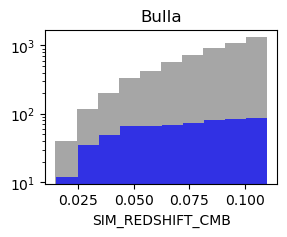

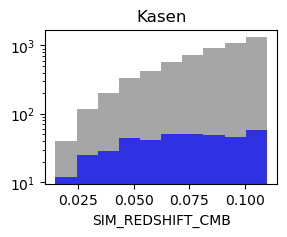

In [ ]:
for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header[df_header.SIM_GENTYPE == typ]
    sel = df_phot[df_phot.SNID.isin(sel_header.SNID)]
    idxs = sel[sel['SNR'] > 5]['SNID'].unique()
    plt.figure(figsize=(3, 2))
    plt.hist(sel_header['SIM_REDSHIFT_CMB'].dropna(), bins=10, color='grey', alpha=0.7)
    plt.hist(sel_header[sel_header.SNID.isin(idxs)]['SIM_REDSHIFT_CMB'].dropna(), bins=10, color='blue', alpha=0.7)
    plt.xlabel('SIM_REDSHIFT_CMB')
    plt.title(dic_sntype[str(typ)])
    plt.yscale('log')

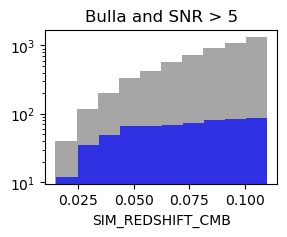

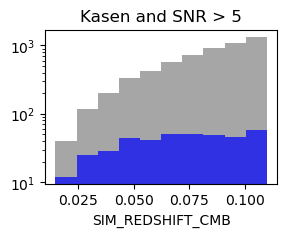

In [ ]:
for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header[df_header.SIM_GENTYPE == typ]
    sel = df_phot[(df_phot.SNID.isin(sel_header.SNID)) & (df_phot['SNR'] > 5)]
    idxs = sel[sel['SNR'] > 5]['SNID'].unique()
    plt.figure(figsize=(3, 2))
    plt.hist(sel_header['SIM_REDSHIFT_CMB'].dropna(), bins=10, color='grey', alpha=0.7)
    plt.hist(sel_header[sel_header.SNID.isin(idxs)]['SIM_REDSHIFT_CMB'].dropna(), bins=10, color='blue', alpha=0.7)
    plt.xlabel('SIM_REDSHIFT_CMB')
    plt.title(f"{dic_sntype[str(typ)]} and SNR > 5")
    plt.yscale('log')

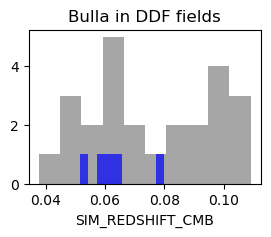

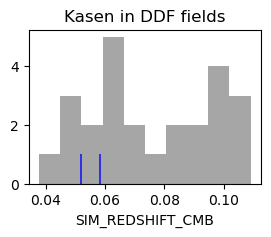

In [ ]:
for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header[(df_header.SIM_GENTYPE == typ) & (df_header.in_ddf_field)]
    sel = df_phot[df_phot.SNID.isin(sel_header.SNID)]
    idxs = sel[sel['SNR'] > 5]['SNID'].unique()
    plt.figure(figsize=(3, 2))
    plt.hist(sel_header['SIM_REDSHIFT_CMB'].dropna(), bins=10, color='grey', alpha=0.7)
    plt.hist(sel_header[sel_header.SNID.isin(idxs)]['SIM_REDSHIFT_CMB'].dropna(), bins=10, color='blue', alpha=0.7)
    plt.xlabel('SIM_REDSHIFT_CMB')
    plt.title(f"{dic_sntype[str(typ)]} in DDF fields")
    # plt.yscale('log')

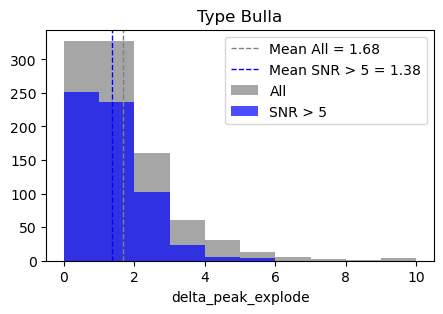

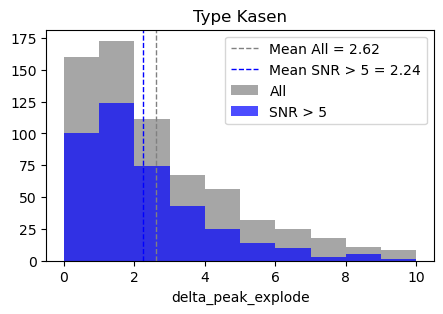

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header[df_header.SIM_GENTYPE == typ].copy()
    sel = df_phot[df_phot.SNID.isin(sel_header.SNID)]
    idxs = sel[sel['SNR'] > 5]['SNID'].unique()
    
    sel_header['delta_peak_explode'] = np.abs(sel_header['PEAKMJD'] - sel_header['SIM_MJD_EXPLODE'])
    
    data_all = sel_header[sel_header['delta_peak_explode'] < 10]['delta_peak_explode'].dropna()
    data_snr = sel_header[(sel_header['delta_peak_explode'] < 10) & (sel_header.SNID.isin(idxs))]['delta_peak_explode'].dropna()
    
    # Define bins once based on data_all
    bins = np.linspace(0, 10, 11)  # 10 bins between 0 and 10
    
    plt.figure(figsize=(5, 3))
    
    plt.hist(data_all, bins=bins, color='grey', alpha=0.7, label='All')
    plt.hist(data_snr, bins=bins, color='blue', alpha=0.7, label='SNR > 5')
    
    # stats
    mean_all = data_all.mean()
    mean_snr = data_snr.mean()
    
    plt.axvline(mean_all, color='grey', linestyle='dashed', linewidth=1, 
                label=f'Mean All = {mean_all:.2f}')
    plt.axvline(mean_snr, color='blue', linestyle='dashed', linewidth=1, 
                label=f'Mean SNR > 5 = {mean_snr:.2f}')
    
    
    plt.xlabel('delta_peak_explode')
    # plt.yscale('log')
    plt.legend()
    plt.title(f'Type {dic_sntype[str(typ)]}')
    plt.show()


In [ ]:
def delta_days(group):
        mjds = group['MJD'].sort_values().values
        for i in range(len(mjds)):
            for j in range(i+1, len(mjds)):
                return mjds[j] - mjds[i]
        return 0
    snids_count_sep_days = sel_gt5.groupby('SNID').apply(lambda x: delta_days(x))

aja

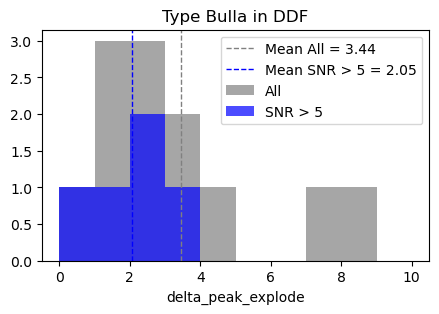

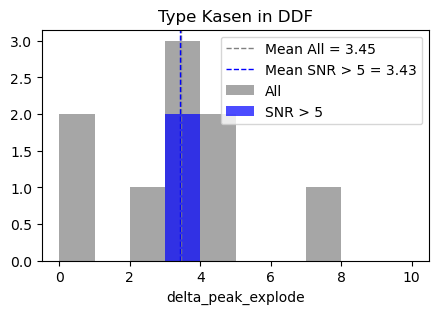

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

for typ in df_header.SIM_GENTYPE.unique():
    sel_header = df_header[(df_header.SIM_GENTYPE == typ) & (df_header.in_ddf_field)].copy()
    sel = df_phot[df_phot.SNID.isin(sel_header.SNID)]
    idxs = sel[sel['SNR'] > 5]['SNID'].unique()
    
    sel_header['delta_peak_explode'] = np.abs(sel_header['PEAKMJD'] - sel_header['SIM_MJD_EXPLODE'])
    
    data_all = sel_header[sel_header['delta_peak_explode'] < 10]['delta_peak_explode'].dropna()
    data_snr = sel_header[(sel_header['delta_peak_explode'] < 10) & (sel_header.SNID.isin(idxs))]['delta_peak_explode'].dropna()
    
    # Define bins once based on data_all
    bins = np.linspace(0, 10, 11)  # 10 bins between 0 and 10
    
    plt.figure(figsize=(5, 3))
    
    plt.hist(data_all, bins=bins, color='grey', alpha=0.7, label='All')
    plt.hist(data_snr, bins=bins, color='blue', alpha=0.7, label='SNR > 5')
    
    # stats
    mean_all = data_all.mean()
    mean_snr = data_snr.mean()
    
    plt.axvline(mean_all, color='grey', linestyle='dashed', linewidth=1, 
                label=f'Mean All = {mean_all:.2f}')
    plt.axvline(mean_snr, color='blue', linestyle='dashed', linewidth=1, 
                label=f'Mean SNR > 5 = {mean_snr:.2f}')
    
    
    plt.xlabel('delta_peak_explode')
    # plt.yscale('log')
    plt.legend()
    plt.title(f'Type {dic_sntype[str(typ)]} in DDF')
    plt.show()


## Delta peak and SNR 5


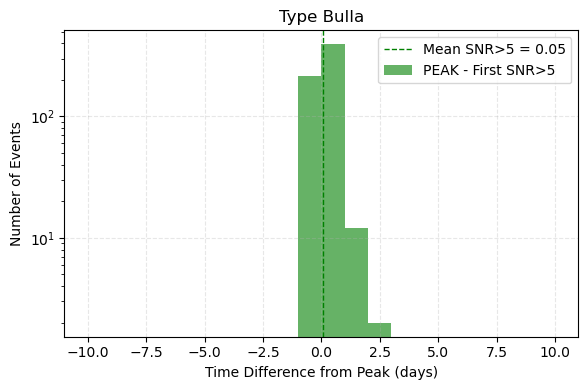

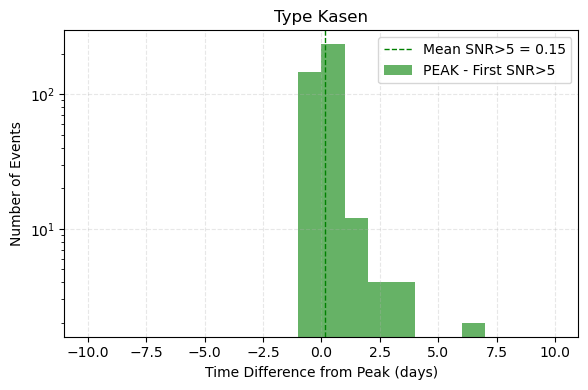

In [ ]:
# Filter to SNR > 5 detections
snr5 = df_phot[df_phot['SNR'] > 5].copy()

# Get first MJD with SNR > 5 per SNID
first_snr5 = snr5.groupby('SNID')['MJD'].min().rename('first_snr5_mjd')

# Merge with header to align with PEAKMJD
df_header = df_header.merge(first_snr5, on='SNID', how='left')

# Compute signed difference: PEAK - first SNR > 5
df_header['delta_peak_snr5'] = np.where(
    df_header['PEAKMJD'] > 0,
    df_header['PEAKMJD'] - df_header['first_snr5_mjd'],
    np.nan
)

for typ in df_header.SIM_GENTYPE.unique():
    # Filter headers for current SN type and DDF field
    sel_header = df_header[(df_header.SIM_GENTYPE == typ)].copy()
    sel_phot = df_phot[df_phot.SNID.isin(sel_header.SNID)].copy()
    
    # Drop NaNs
    data_snr5 = sel_header['delta_peak_snr5'].dropna()

    # Histogram bins
    bins = np.linspace(-10, 10, 21)  # From -10 to +10 in 1-day steps

    plt.figure(figsize=(6, 4))

    plt.hist(data_snr5, bins=bins, color='green', alpha=0.6, label='PEAK - First SNR>5')

    # Stats lines
    mean_snr5 = data_snr5.mean()

    plt.axvline(mean_snr5, color='green', linestyle='--', linewidth=1,
                label=f'Mean SNR>5 = {mean_snr5:.2f}')

    plt.xlabel('Time Difference from Peak (days)')
    plt.ylabel('Number of Events')
    plt.title(f'Type {dic_sntype[str(typ)]}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.yscale('log')
    plt.show()
